In [ ]:

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    import subprocess
    subprocess.run(['nvidia-smi', '-L'])

!pip install -q torch torchvision pandas numpy scikit-learn pillow matplotlib opencv-python tqdm timm torchcam 2>&1 | tail -3

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/oculis/retina-ai'
for d in ['ai', 'vision', 'models', 'data', 'artifacts']:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
print("✓ Directories created at", BASE)

Mounted at /content/drive
✓ Directories created at /content/drive/MyDrive/oculis/retina-ai


In [ ]:
# @title Setup Kaggle API Credentials
# 1. Download your kaggle.json from kaggle.com -> Account -> Create New API Token
# 2. Upload kaggle.json to Colab or configure your environment variables
import os
import json

# If you uploaded kaggle.json to /content/kaggle.json:
os.makedirs('/root/.kaggle', exist_ok=True)
if os.path.exists('/content/kaggle.json'):
    import shutil
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('Kaggle API configured successfully')
else:
    print('Please upload kaggle.json to /content/kaggle.json')


In [10]:

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json 2>/dev/null || echo "Upload kaggle.json first!"
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p /content/data/ 2>&1 | tail -5

!unzip -q /content/data/aptos2019-blindness-detection.zip -d /content/data/
!unzip -q /content/data/train_images.zip -d /content/data/ 2>/dev/null
!unzip -q /content/data/test_images.zip -d /content/data/ 2>/dev/null

print("✓ Dataset ready at /content/data/")

Upload kaggle.json first!
100%|██████████| 9.51G/9.51G [07:55<00:00, 21.5MB/s]

✓ Dataset ready at /content/data/


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

train_csv = pd.read_csv('/content/data/train.csv')
print("Shape:", train_csv.shape)
print("\nClass distribution:")
print(train_csv['diagnosis'].value_counts().sort_index())


train_df, val_df = train_test_split(
    train_csv,
    test_size=0.20,
    stratify=train_csv['diagnosis'],
    random_state=42
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")
print("\nTrain dist:\n", train_df['diagnosis'].value_counts(normalize=True).sort_index())
print("\nVal dist:\n",   val_df['diagnosis'].value_counts(normalize=True).sort_index())


train_df.to_csv(f'{BASE}/data/train_split.csv', index=False)
val_df.to_csv(f'{BASE}/data/val_split.csv', index=False)
print("\n✓ Splits saved to Drive")

Shape: (3662, 2)

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Train: 2929 | Val: 733

Train dist:
 diagnosis
0    0.493001
1    0.101058
2    0.272789
3    0.052578
4    0.080574
Name: proportion, dtype: float64

Val dist:
 diagnosis
0    0.492497
1    0.100955
2    0.272851
3    0.053206
4    0.080491
Name: proportion, dtype: float64

✓ Splits saved to Drive


In [ ]:

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class APTOSDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['id_code'] + '.png')
        image = Image.open(img_path).convert('RGB')
        label = int(row['diagnosis'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = APTOSDataset(f'{BASE}/data/train_split.csv', '/content/data/train_images', train_transform)
val_ds   = APTOSDataset(f'{BASE}/data/val_split.csv', '/content/data/train_images', val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # torch.Size([32, 3, 224, 224])
print(f"Labels: {labels[:10]}")
print(f"Range: {images.min():.3f} to {images.max():.3f}")

Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([2, 1, 0, 2, 0, 2, 1, 4, 0, 2])
Range: -2.118 to 2.640


In [ ]:

import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_model(num_classes=5, freeze_backbone=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
    return model.to(device), device

def unfreeze_layers(model, num_blocks_to_unfreeze=3):
    blocks = ['6', '5', '4'][:num_blocks_to_unfreeze]
    for name, param in model.named_parameters():
        if any(f'features.{b}' in name for b in blocks):
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    return model


model, device = build_model(freeze_backbone=True)
dummy = torch.randn(4, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}")  # [4, 5]

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]


Output shape: torch.Size([4, 5])


In [ ]:

from collections import Counter
from sklearn.metrics import accuracy_score

def compute_class_weights(labels, num_classes=5):
    counts = Counter(labels)
    total = sum(counts.values())
    return torch.tensor([total / (num_classes * counts.get(c, 1)) for c in range(num_classes)], dtype=torch.float32)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds), all_preds, all_labels, all_probs

config = {
    'stage1_epochs': 5, 'stage1_lr': 1e-3,
    'stage2_epochs': 5, 'stage2_lr': 1e-4,
    'weight_decay': 1e-4,
    'model_save_path': f'{BASE}/models/best_model.pth',
    'num_classes': 5,
}

print("="*50); print("STAGE 1: Frozen backbone"); print("="*50)
all_train_labels = [l for _, l in train_loader]
class_weights = compute_class_weights(all_train_labels).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=config['stage1_lr'], weight_decay=config['weight_decay'])

best_val_acc = 0.0
for epoch in range(config['stage1_epochs']):
    tl, ta = train_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, _, _, _ = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{config['stage1_epochs']} | Train: {tl:.4f}/{ta:.4f} | Val: {vl:.4f}/{va:.4f}")
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), config['model_save_path'])
        print(f"  ✓ Saved best (val_acc={va:.4f})")


print("="*50); print("STAGE 2: Fine-tune"); print("="*50)
model = unfreeze_layers(model, 3)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=config['stage2_lr'], weight_decay=config['weight_decay'])

for epoch in range(config['stage2_epochs']):
    tl, ta = train_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, _, _, _ = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{config['stage2_epochs']} | Train: {tl:.4f}/{ta:.4f} | Val: {vl:.4f}/{va:.4f}")
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), config['model_save_path'])
        print(f"  ✓ Saved best (val_acc={va:.4f})")

print(f"\n✅ Training complete. Best val_acc: {best_val_acc:.4f}")

STAGE 1: Frozen backbone
Epoch 1/5 | Train: 0.9791/0.6480 | Val: 0.8466/0.7040
  ✓ Saved best (val_acc=0.7040)
Epoch 2/5 | Train: 0.7544/0.7303 | Val: 0.7860/0.7108
  ✓ Saved best (val_acc=0.7108)
Epoch 3/5 | Train: 0.7035/0.7412 | Val: 0.7773/0.7080
Epoch 4/5 | Train: 0.6752/0.7562 | Val: 0.7490/0.7190
  ✓ Saved best (val_acc=0.7190)
Epoch 5/5 | Train: 0.6469/0.7610 | Val: 0.7427/0.7149
STAGE 2: Fine-tune
Trainable: 2,818,831 / 4,013,953 (70.2%)
Epoch 1/5 | Train: 0.5726/0.7866 | Val: 0.6468/0.7653
  ✓ Saved best (val_acc=0.7653)
Epoch 2/5 | Train: 0.4791/0.8191 | Val: 0.6297/0.7681
  ✓ Saved best (val_acc=0.7681)
Epoch 3/5 | Train: 0.4588/0.8310 | Val: 0.6087/0.7749
  ✓ Saved best (val_acc=0.7749)
Epoch 4/5 | Train: 0.4097/0.8515 | Val: 0.6081/0.7735
Epoch 5/5 | Train: 0.3684/0.8713 | Val: 0.5964/0.7722

✅ Training complete. Best val_acc: 0.7749


In [ ]:

import json


class_names = {
    "0": "No DR", "1": "Mild NPDR", "2": "Moderate NPDR",
    "3": "Severe NPDR", "4": "Proliferative DR"
}
with open(f'{BASE}/models/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)


with open(f'{BASE}/models/config.json', 'w') as f:
    json.dump({
        'model': 'efficientnet_b0',
        'pretrained': 'IMAGENET1K_V1',
        'num_classes': 5,
        'img_size': 224,
        'imagenet_mean': [0.485, 0.456, 0.406],
        'imagenet_std': [0.229, 0.224, 0.225],
        **config
    }, f, indent=2)

print("✓ Metadata saved to Drive")

✓ Metadata saved to Drive


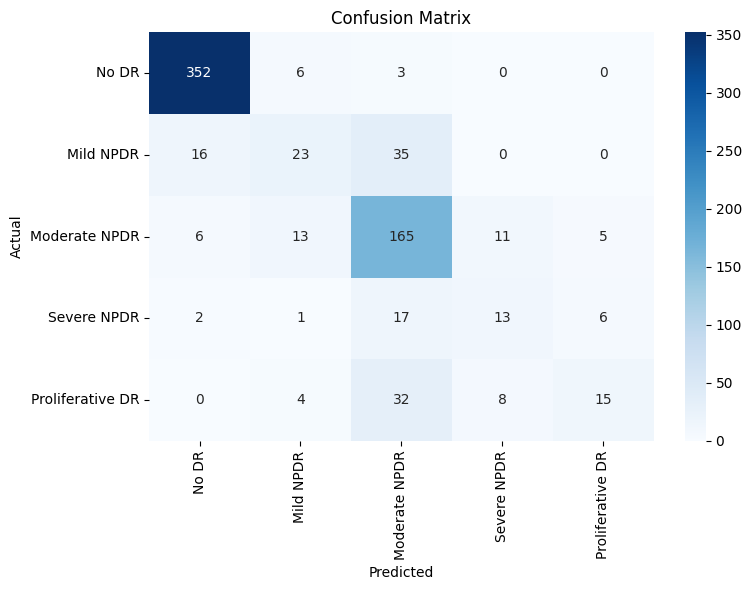


EVALUATION REPORT

5-Class Accuracy:     0.7749
5-Class Macro F1:     0.5569

REFERABLE DR (≥ Level 2)
Sensitivity:          0.9128
Specificity:          0.9126
ROC-AUC:              0.9713

PER-CLASS:
  No DR                  P:0.936 R:0.975 F1:0.955 (n=361)
  Mild NPDR              P:0.489 R:0.311 F1:0.380 (n=74)
  Moderate NPDR          P:0.655 R:0.825 F1:0.730 (n=200)
  Severe NPDR            P:0.406 R:0.333 F1:0.366 (n=39)
  Proliferative DR       P:0.577 R:0.254 F1:0.353 (n=59)

✅ MEETS SIH TARGET (≥90% sens, ≥85% spec)


In [ ]:

import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import json

CLASS_NAMES = ['No DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'Proliferative DR']


model.load_state_dict(torch.load(f'{BASE}/models/best_model.pth', map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# 5-class metrics
results = {
    'accuracy': float(accuracy_score(all_labels, all_preds)),
    'macro_f1': float(f1_score(all_labels, all_preds, average='macro')),
    'weighted_f1': float(f1_score(all_labels, all_preds, average='weighted')),
    'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist(),
    'per_class': {},
    'referable_dr': {}
}

for i in range(5):
    tp = np.sum((all_preds == i) & (all_labels == i))
    fp = np.sum((all_preds == i) & (all_labels != i))
    fn = np.sum((all_preds != i) & (all_labels == i))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    results['per_class'][f'class_{i}'] = {
        'name': CLASS_NAMES[i], 'precision': float(prec), 'recall': float(rec),
        'f1': float(f1), 'support': int(np.sum(all_labels == i))
    }

# Referable DR
y_true_ref = (all_labels >= 2).astype(int)
y_pred_ref = (all_preds >= 2).astype(int)
ref_prob = all_probs[:, 2:].sum(axis=1)
tn = np.sum((y_true_ref == 0) & (y_pred_ref == 0))
fp = np.sum((y_true_ref == 0) & (y_pred_ref == 1))
fn = np.sum((y_true_ref == 1) & (y_pred_ref == 0))
tp = np.sum((y_true_ref == 1) & (y_pred_ref == 1))
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

results['referable_dr'] = {
    'sensitivity': float(sensitivity), 'specificity': float(specificity),
    'precision': float(precision_score(y_true_ref, y_pred_ref, zero_division=0)),
    'recall': float(recall_score(y_true_ref, y_pred_ref)),
    'f1': float(f1_score(y_true_ref, y_pred_ref)),
    'roc_auc': float(roc_auc_score(y_true_ref, ref_prob)),
}

with open(f'{BASE}/artifacts/evaluation_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

plt.figure(figsize=(8, 6))
sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{BASE}/artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print report
print("\n" + "="*60); print("EVALUATION REPORT"); print("="*60)
print(f"\n5-Class Accuracy:     {results['accuracy']:.4f}")
print(f"5-Class Macro F1:     {results['macro_f1']:.4f}")
print(f"\nREFERABLE DR (≥ Level 2)")
print(f"Sensitivity:          {results['referable_dr']['sensitivity']:.4f}")
print(f"Specificity:          {results['referable_dr']['specificity']:.4f}")
print(f"ROC-AUC:              {results['referable_dr']['roc_auc']:.4f}")
print("\nPER-CLASS:")
for i in range(5):
    pc = results['per_class'][f'class_{i}']
    print(f"  {CLASS_NAMES[i]:<22} P:{pc['precision']:.3f} R:{pc['recall']:.3f} F1:{pc['f1']:.3f} (n={pc['support']})")

if results['referable_dr']['sensitivity'] >= 0.90 and results['referable_dr']['specificity'] >= 0.85:
    print("\n✅ MEETS SIH TARGET (≥90% sens, ≥85% spec)")
else:
    print("\n⚠ Below target — consider more epochs/data")

In [ ]:

from PIL import Image
import torch.nn.functional as F


test_img_path = '/content/data/train_images/' + val_ds.df.iloc[0]['id_code'] + '.png'
pil_img = Image.open(test_img_path).convert('RGB')

tensor = val_transform(pil_img).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(tensor)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()

pred_level = int(probs.argmax())
result = {
    'level': pred_level,
    'label': CLASS_NAMES[pred_level],
    'scores': {CLASS_NAMES[i]: float(probs[i]) for i in range(5)},
    'referable': pred_level >= 2
}

import json
print(json.dumps(result, indent=2))


!cd {BASE} && zip -r oculis_deliverable.zip \
    models/best_model.pth \
    models/class_names.json \
    models/config.json \
    ai/predict.py \
    ai/model.py \
    ai/dataset.py \
    vision/gradcam.py \
    artifacts/evaluation_metrics.json \
    artifacts/confusion_matrix.png 2>/dev/null

from google.colab import files
files.download(f'{BASE}/oculis_deliverable.zip')
print("✅ Deliverable downloaded!")

{
  "level": 0,
  "label": "No DR",
  "scores": {
    "No DR": 0.9939555525779724,
    "Mild NPDR": 0.0037073951680213213,
    "Moderate NPDR": 0.0021415473893284798,
    "Severe NPDR": 0.00011262914631515741,
    "Proliferative DR": 8.278191671706736e-05
  },
  "referable": false
}
	zip warning: name not matched: ai/predict.py
	zip warning: name not matched: ai/model.py
	zip warning: name not matched: ai/dataset.py
	zip warning: name not matched: vision/gradcam.py
  adding: models/best_model.pth (deflated 8%)
  adding: models/class_names.json (deflated 35%)
  adding: models/config.json (deflated 44%)
  adding: artifacts/evaluation_metrics.json (deflated 65%)
  adding: artifacts/confusion_matrix.png (deflated 16%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Deliverable downloaded!
